# Deliverable 4 — Personalisation: Fine-Tuning, Split-FL, and Ditto
**CS437/CS5317 Deep Learning, Spring 2026 | Group 30**
Muhammad Umar Malik (27100139) · Muhammad Moosa Kashif (27100451)

---

This notebook asks whether the global FedAvg model from D3 is leaving per-client performance on the table, and whether personalisation can recover it. We test three strategies.

**FT-k.** After FedAvg converges, each client runs k additional gradient epochs on its own private data. The idea is that the global model has been pulled toward a cross-market average, and a small amount of local gradient descent should push it back toward each client's own optimum. We test k ∈ {0, 1, 3, 5, 10, 20} with per-client learning rate selection on the validation set.

**Split-FL.** Rather than fine-tuning after training, we split the model from the start. The LSTM backbone is shared and trained federally; each client keeps its own private output head that is never sent to the server. The backbone learns cross-market temporal representations; the head learns market-specific allocation on top of them.

**Ditto** (Li et al., NeurIPS 2021). Each client trains a separate local model alongside the global FedAvg model, with a proximal term pulling it toward the current global weights. Unlike FT-k, the local model develops from the beginning of training — not just as a post-hoc fine-tuning step.

The Hellinger Distance scores from D3 are carried forward to test whether pre-training heterogeneity predicts which clients benefit most from personalisation.

**Architecture upgrade.** This notebook upgrades to hidden=128, 2-layer LSTM (~163K params). The D3 architecture (hidden=64, 1 layer) converged to a region of the loss surface where fine-tuning produced changes too small to be statistically meaningful.

---
## Section 0 — Environment

In [1]:
import os, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import torch
import torch.nn as nn
from scipy.stats import norm, wilcoxon, pearsonr

warnings.filterwarnings('ignore')
FIGURES_DIR = 'Figures_imp1'
os.makedirs(FIGURES_DIR, exist_ok=True)

SEEDS = list(range(42, 52))
torch.manual_seed(SEEDS[0])
np.random.seed(SEEDS[0])

print(f'PyTorch  : {torch.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'Seeds    : {SEEDS}  ({len(SEEDS)} total)')
print(f'Figures  -> {FIGURES_DIR}/')

PyTorch  : 2.10.0+cu128
NumPy    : 2.0.2
Pandas   : 2.3.3
Seeds    : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]  (10 total)
Figures  -> Figures_imp1/


---
## Section 1 — Configuration

In [2]:
DATA_DIR = '/kaggle/input/datasets/umarmalikk/updated-set/data'
# DATA_DIR = '/Users/muhammad/Documents/Spring_26/Deep_Learning/Project/expanded_dataset/data'
MARKETS     = ['SP500', 'FTSE100', 'KSE100', 'Nikkei225']
DEV_MARKETS = ['SP500', 'FTSE100', 'Nikkei225']

TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2021-12-31'
TEST_START = '2022-01-01'
TEST_END   = '2026-04-01'

REGIMES = {
    '2022 Inflation shock': ('2022-01-01', '2022-12-31'),
    '2023 Recovery'       : ('2023-01-01', '2023-12-31'),
    '2024+ Late cycle'    : ('2024-01-01', '2026-04-01'),
}

WINDOW        = 100
TRADING_DAYS  = 252
RF_ANNUAL     = 0.02
RF_DAILY      = RF_ANNUAL / TRADING_DAYS
TC            = 0.001
LAMBDA_TC     = 0.01
GRAD_CLIP     = 1.0
STD_FLOOR     = 1e-4
# MAX_FL_ROUNDS = 100
MAX_FL_ROUNDS = 150
# LOCAL_EPOCHS  = 2
LOCAL_EPOCHS  = 5
# LOCAL_LR      = 1e-3
LOCAL_LR      = 5e-4
# BATCH_SIZE    = 256
BATCH_SIZE    = 128
# PATIENCE      = 10
PATIENCE      = 15
N_BOOTSTRAP   = 1000
BLOCK_SIZE    = 21

# Upgraded architecture: D3 used hidden=64, 1 layer (40,911 params).
# We use hidden=128, 2 layers (~163K params). The D3 architecture converges
# to a flat region of the Sharpe landscape; the upgrade gives the model enough
# capacity to learn hierarchical temporal representations and gives fine-tuning
# directions in weight space to exploit.
# HIDDEN_DIM  = 128
HIDDEN_DIM = 96
NUM_LAYERS  = 2

# FT-k grid
FINETUNE_EPOCHS  = [0, 1, 3, 5, 10, 20]
FINETUNE_LR_GRID = [1e-5, 5e-5]
FINETUNE_LR      = 5e-5  
LAMBDA_ANCHOR    = 0.05

# Ditto proximal weights to test — μ controls local vs global trade-off
# DITTO_MU_GRID = [0.01, 0.1, 1.0]
DITTO_MU_GRID = [0.01, 0.1, 0.3, 1.0]
DITTO_MU      = 0.1    # selected per-market on val set, this is the default

# Split-FL head learning rate (backbone LR reuses LOCAL_LR)
SPLIT_HEAD_LR = 1e-3

# D3 reference Sharpe values
D3_SHARPE = {
    'EqWt'   : {'SP500':0.6330, 'FTSE100':0.5669, 'KSE100':0.8487, 'Nikkei225':0.8884},
    'Local'  : {'SP500':0.8927, 'FTSE100':0.4642, 'KSE100':0.8235,'Nikkei225':0.7618},
    'Central': {'SP500':0.9289, 'FTSE100':0.4979, 'KSE100':0.9352, 'Nikkei225':0.8515},
    'FedAvg' : {'SP500':0.9498, 'FTSE100':0.5099, 'KSE100':0.9375, 'Nikkei225':0.8664},
}

HD_SCORES = {
    'Nikkei225': 0.1133,
    'FTSE100':   0.0920,
    'SP500':     0.0818,
    'KSE100':    0.0732,
}
COLORS    = {'SP500':'#1f77b4','FTSE100':'#ff7f0e','KSE100':'#2ca02c','Nikkei225':'#d62728'}

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu')

print('Configuration loaded.')
print(f'  Architecture : hidden={HIDDEN_DIM}, layers={NUM_LAYERS}')
print(f'  FT-k grid    : k={FINETUNE_EPOCHS}, LR={FINETUNE_LR_GRID}')
print(f'  Split-FL     : shared backbone + per-client head, head_lr={SPLIT_HEAD_LR}')
print(f'  Device       : {device}')

Configuration loaded.
  Architecture : hidden=96, layers=2
  FT-k grid    : k=[0, 1, 3, 5, 10, 20], LR=[1e-05, 5e-05]
  Split-FL     : shared backbone + per-client head, head_lr=0.001
  Device       : cuda


---
## Section 2 — Data Loading

In [3]:
def load_prices(market):
    df = pd.read_csv(os.path.join(DATA_DIR, f'{market}_prices.csv'),
                     index_col=0, parse_dates=True)
    return df.sort_index()

def compute_log_returns(prices_df):
    filled = prices_df.ffill()
    return np.log(filled / filled.shift(1)).dropna(how='all')

def make_splits(returns_df):
    return {'train': returns_df.loc[:TRAIN_END],
            'val'  : returns_df.loc[VAL_START:VAL_END],
            'test' : returns_df.loc[TEST_START:TEST_END]}

prices   = {m: load_prices(m)                 for m in MARKETS}
returns  = {m: compute_log_returns(prices[m]) for m in MARKETS}
splits   = {m: make_splits(returns[m])        for m in MARKETS}
n_assets = {m: prices[m].shape[1]             for m in MARKETS}

rows = [{'Market':m,'Assets':prices[m].shape[1],
         'Train':len(splits[m]['train']),'Val':len(splits[m]['val']),
         'Test':len(splits[m]['test'])} for m in MARKETS]
print(pd.DataFrame(rows).set_index('Market').to_string())

           Assets  Train  Val  Test
Market                             
SP500          30   2515  505  1064
FTSE100        30   2525  507  1071
KSE100         30   2478  498  1051
Nikkei225      30   2468  487  1036


---
## Section 3 — Feature Engineering

In [4]:
def engineer_features(ret_df):
    R = ret_df.ffill().fillna(0.0)
    frames = [
        R.copy(),
        R.rolling(5,  min_periods=1).mean(),
        R.rolling(20, min_periods=2).std().fillna(0.0),
        (R.rolling(20, min_periods=2).mean() /
         R.rolling(20, min_periods=2).std().replace(0, np.nan)).fillna(0.0),
        R.rolling(20, min_periods=3).skew().fillna(0.0),
        R.rolling(60, min_periods=1).sum(),
    ]
    combined = pd.concat(frames, axis=1)
    combined.columns = [f'f{k}_{c}' for k in range(6) for c in R.columns]
    return combined.iloc[60:].copy()

def fit_norm(feat_df):
    return feat_df.mean(), feat_df.std().replace(0, 1.0)

def apply_norm(feat_df, mu, sig, clip=5.0):
    return ((feat_df - mu) / sig).clip(-clip, clip)

def make_sequences(feat_df, ret_df, window=WINDOW):
    fa = feat_df.values.astype(np.float32)
    ra = ret_df.reindex(feat_df.index).ffill().fillna(0.0).values.astype(np.float32)
    X, y = [], []
    for i in range(window, len(fa)):
        X.append(fa[i-window:i]); y.append(ra[i])
    Xt = torch.from_numpy(np.array(X, dtype=np.float32)).to(device)
    yt = torch.from_numpy(np.array(y, dtype=np.float32)).to(device)
    return Xt, yt

features_all = {m: engineer_features(returns[m]) for m in MARKETS}
normalisers  = {}
train_seq, val_seq, test_seq = {}, {}, {}
n_features = {}

for m in MARKETS:
    f = features_all[m]
    f_tr = f.loc[:TRAIN_END]
    f_v  = f.loc[VAL_START:VAL_END]
    f_te = f.loc[TEST_START:TEST_END]
    mu, sig = fit_norm(f_tr)
    normalisers[m] = (mu, sig)
    train_seq[m] = make_sequences(apply_norm(f_tr, mu, sig), splits[m]['train'])
    val_seq[m]   = make_sequences(apply_norm(f_v,  mu, sig), splits[m]['val'])
    test_seq[m]  = make_sequences(apply_norm(f_te, mu, sig), splits[m]['test'])
    n_features[m] = train_seq[m][0].shape[2]

print(f'All tensors on: {device}')
for m in MARKETS:
    X, y = train_seq[m]
    print(f'  {m:<12} X={tuple(X.shape)}  y={tuple(y.shape)}')

for m in MARKETS:
    print(f'{m}: X_train mean={train_seq[m][0].mean():.6f}, std={train_seq[m][0].std():.6f}')

All tensors on: cuda
  SP500        X=(2355, 100, 180)  y=(2355, 30)
  FTSE100      X=(2365, 100, 180)  y=(2365, 30)
  KSE100       X=(2318, 100, 180)  y=(2318, 30)
  Nikkei225    X=(2308, 100, 180)  y=(2308, 30)
SP500: X_train mean=0.001205, std=0.993363
FTSE100: X_train mean=-0.000686, std=0.990747
KSE100: X_train mean=-0.005710, std=0.991070
Nikkei225: X_train mean=0.000504, std=0.999096


---
## Section 4 — Model Architectures

Two model classes are defined here. Both share the same LSTM backbone design.

**LSTMPortfolio** is used for FT-k and Ditto. Standard 2-layer LSTM with a shared linear output head trained with FedAvg, personalised post-hoc.

**SplitLSTM** is used for Split-FL. The LSTM backbone is identical, but the output head is separated. The backbone is aggregated federally each round. Each client's head stays private and is never sent to the server. During local training, gradients flow through both backbone and head. The key difference from FT-k is that the head trains on private data from round one, not only in a post-convergence fine-tuning phase.

In [5]:
class LSTMPortfolio(nn.Module):
    """
    Input  : (B, window, 6*n_assets)
    LSTM   : num_layers layers, hidden_dim units
    Output : (B, n_assets) softmax portfolio weights

    Used for FedAvg global model and FT-k fine-tuning.
    """
    def __init__(self, n_feat, n_assets, hidden=HIDDEN_DIM, layers=NUM_LAYERS, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(p=dropout)
        self.fc   = nn.Linear(hidden, n_assets)

    def forward(self, x):
        out, _ = self.lstm(x)
        return torch.softmax(self.fc(self.drop(out[:, -1, :])), dim=-1)


class SplitLSTM(nn.Module):
    """
    Shared backbone (LSTM + dropout) + private per-client head (Linear).

    The backbone() method returns the hidden representation before the head,
    allowing the server to aggregate only backbone weights. The head is
    initialised fresh per client and never leaves the client.

    Used for Split-FL.
    """
    def __init__(self, n_feat, n_assets, hidden=HIDDEN_DIM, layers=NUM_LAYERS, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden, n_assets)

    def backbone(self, x):
        out, _ = self.lstm(x)
        return self.drop(out[:, -1, :])

    def forward(self, x):
        return torch.softmax(self.head(self.backbone(x)), dim=-1)

    def backbone_state(self):
        """State dict containing only backbone parameters (lstm + drop)."""        
        return {k: v.clone() for k, v in self.state_dict().items()
                if k.startswith('lstm') or k.startswith('drop')}

    def load_backbone(self, state):
        """Load backbone weights without touching the head."""        
        current = self.state_dict()
        current.update(state)
        self.load_state_dict(current)


def make_model(market, seed):
    """Fresh LSTMPortfolio with per-market seed reset. Matches D3's make_model exactly."""    
    torch.manual_seed(seed)
    return LSTMPortfolio(n_features[market], n_assets[market]).to(device)

def make_split_model(market, seed):
    """Fresh SplitLSTM with per-market seed reset."""    
    torch.manual_seed(seed)
    return SplitLSTM(n_features[market], n_assets[market]).to(device)

# Sanity checks
_nf, _na = n_features[MARKETS[0]], n_assets[MARKETS[0]]
m1 = LSTMPortfolio(_nf, _na).to(device)
m2 = SplitLSTM(_nf, _na).to(device)
xd = torch.randn(4, WINDOW, _nf).to(device)
p1 = sum(p.numel() for p in m1.parameters())
p2 = sum(p.numel() for p in m2.parameters())
bb = sum(p.numel() for k,p in m2.named_parameters() if not k.startswith('head'))
hd = sum(p.numel() for k,p in m2.named_parameters() if k.startswith('head'))
print(f'LSTMPortfolio : {p1:,} params  | output sums ~1: {m1(xd).sum(1).min().item():.4f}')
print(f'SplitLSTM     : {p2:,} params  | backbone={bb:,}  head={hd:,}')
print(f'  Backbone is {bb/p2*100:.1f}% of total params (aggregated federally)')
print(f'  Head     is {hd/p2*100:.1f}% of total params (stays private per client)')
del m1, m2, xd

LSTMPortfolio : 184,158 params  | output sums ~1: 1.0000
SplitLSTM     : 184,158 params  | backbone=181,248  head=2,910
  Backbone is 98.4% of total params (aggregated federally)
  Head     is 1.6% of total params (stays private per client)


---
## Section 5 — Loss Function and Evaluation

Same Sharpe loss as D3: negative Sharpe ratio with turnover penalty λ=0.01. Evaluation applies 10 bps one-way transaction costs on daily weight changes.

In [6]:
def portfolio_loss(weights, next_returns, prev_weights=None, eps=1e-8):
    port_rets = (weights * next_returns).sum(dim=1)
    std_ret   = torch.clamp(port_rets.std(), min=STD_FLOOR) + eps
    sharpe    = (port_rets.mean() - RF_DAILY) / std_ret * TRADING_DAYS**0.5
    loss      = -sharpe
    if prev_weights is not None and prev_weights.shape == weights.shape:
        loss = loss + LAMBDA_TC * (weights - prev_weights).abs().sum(dim=1).mean()
    return loss

def compute_metrics(port_rets):
    ann_ret = port_rets.mean() * TRADING_DAYS
    ann_vol = port_rets.std()  * TRADING_DAYS**0.5
    sharpe  = (port_rets.mean() - RF_DAILY) / (port_rets.std() + 1e-9) * TRADING_DAYS**0.5
    down    = port_rets[port_rets < 0]
    sortino = (port_rets.mean() - RF_DAILY) / (down.std() + 1e-9) * TRADING_DAYS**0.5
    cum     = np.cumprod(1 + np.clip(port_rets, -0.999, None))
    max_dd  = (cum / np.maximum.accumulate(cum) - 1).min()
    calmar  = ann_ret / (abs(max_dd) + 1e-9)
    return dict(ann_ret=ann_ret, ann_vol=ann_vol, sharpe=sharpe,
                sortino=sortino, calmar=calmar, max_dd=max_dd, cum_ret=cum)

def evaluate_portfolio(model, Xt, yt):
    model.eval()
    with torch.no_grad():
        w = model(Xt).cpu().numpy()
    r  = (w * yt.cpu().numpy()).sum(axis=1)
    to = np.abs(np.diff(w, axis=0)).sum(axis=1)
    r[1:] -= TC * to
    m = compute_metrics(r)
    return {**m, 'turnover': to.mean(), 'daily_rets': r, 'weights': w}

print('Loss and evaluation defined. Identical to D3.')

Loss and evaluation defined. Identical to D3.


---
## Section 6 — Statistical Tests

In [7]:
def block_bootstrap_sharpe(daily_rets, n_boot=N_BOOTSTRAP, block=BLOCK_SIZE):
    T = len(daily_rets)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        idx = []
        while len(idx) < T:
            s = np.random.randint(0, T); idx.extend(range(s, s + block))
        r = daily_rets[np.array(idx[:T]) % T]
        boot[i] = (r.mean() - RF_DAILY) / (r.std() + 1e-9) * TRADING_DAYS**0.5
    return boot.mean(), boot.std(), np.percentile(boot, 2.5), np.percentile(boot, 97.5)

def jobson_korkie(r_a, r_b):
    T = min(len(r_a), len(r_b)); r_a, r_b = r_a[-T:], r_b[-T:]
    mu_a, mu_b = r_a.mean(), r_b.mean()
    s_a,  s_b  = r_a.std(),  r_b.std()
    rho  = np.clip(np.corrcoef(r_a, r_b)[0, 1], -1+1e-6, 1-1e-6)
    SR_a = (mu_a - RF_DAILY) / (s_a + 1e-9) * TRADING_DAYS**0.5
    SR_b = (mu_b - RF_DAILY) / (s_b + 1e-9) * TRADING_DAYS**0.5
    theta = 2 - 2*rho + 0.5*(SR_a**2 + SR_b**2) - SR_a*SR_b*(1 + rho**2/2)
    se = max(np.sqrt(max(theta, 0) / T), 1.0 / T**0.5)
    z  = (SR_a - SR_b) / se
    return float(z), float(2*(1 - norm.cdf(abs(z))))

def wilcoxon_test(sa, sb):
    diffs = np.array(sa) - np.array(sb)
    if np.all(diffs == 0): return 0.0, 1.0
    try:    stat, p = wilcoxon(diffs, alternative='two-sided', zero_method='wilcox')
    except: stat, p = 0.0, 1.0
    return float(stat), float(p)

print('Statistical tests defined.')
print('  Block bootstrap: 1000x block=21d | JK: Memmel (2003) | Wilcoxon: signed-rank n=10')
print('  Significance criterion: JK p<0.05 AND Wilcoxon p<0.05 (dual)')

Statistical tests defined.
  Block bootstrap: 1000x block=21d | JK: Memmel (2003) | Wilcoxon: signed-rank n=10
  Significance criterion: JK p<0.05 AND Wilcoxon p<0.05 (dual)


---
## Section 7 — FedAvg Training Infrastructure

Identical to D3 in every detail: sample-weighted aggregation, patience=10 on aggregate validation Sharpe, 2 local epochs per round, gradient clipping at norm=1.0. The only difference is the upgraded architecture.

In [8]:
def local_train(model, X_tr, y_tr, epochs=LOCAL_EPOCHS, lr=LOCAL_LR, bs=BATCH_SIZE):
    lm = LSTMPortfolio(model.lstm.input_size, model.fc.out_features).to(device)
    lm.load_state_dict(model.state_dict())
    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    lm.train()
    n = X_tr.shape[0]
    for _ in range(epochs):
        perm, prev_w = torch.randperm(n, device=device), None
        for s in range(0, n, bs):
            idx = perm[s:s+bs]; x_b, y_b = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            w_b  = lm(x_b)
            loss = portfolio_loss(w_b, y_b, prev_w)
            loss.backward()
            nn.utils.clip_grad_norm_(lm.parameters(), GRAD_CLIP)
            opt.step()
            prev_w = w_b.detach()
    return {k: v.clone() for k, v in lm.state_dict().items()}

def fedavg_aggregate(client_weights, client_sizes):
    total = sum(client_sizes)
    return {key: sum(cw[key].float() * (nk / total)
                     for cw, nk in zip(client_weights, client_sizes))
            for key in client_weights[0]}

def run_fedavg(seed, markets=None, verbose=False):
    if markets is None: markets = MARKETS
    np.random.seed(seed)
    models   = {m: make_model(m, seed) for m in markets}
    history  = {m: [] for m in markets}
    best_agg = -np.inf
    best_sd  = {m: copy.deepcopy(models[m].state_dict()) for m in markets}
    pat, nrds = 0, 0
    for rnd in range(1, MAX_FL_ROUNDS + 1):
        sds, sizes = [], []
        for m in markets:
            sds.append(local_train(models[m], *train_seq[m]))
            sizes.append(len(train_seq[m][0]))
        gsd = fedavg_aggregate(sds, sizes)
        for m in markets: models[m].load_state_dict(gsd)
        agg = 0.0
        for m in markets:
            s = evaluate_portfolio(models[m], *val_seq[m])['sharpe']
            history[m].append(s); agg += s
        agg /= len(markets); nrds = rnd
        if agg > best_agg + 1e-4:
            best_agg = agg
            best_sd  = {m: copy.deepcopy(models[m].state_dict()) for m in markets}
            pat = 0
        else:
            pat += 1
            if pat >= PATIENCE: break
    for m in markets: models[m].load_state_dict(best_sd[m])
    return models, nrds, history

print('FedAvg infrastructure defined.')

FedAvg infrastructure defined.


---
## Section 8 — Fine-Tuning (FT-k)

After FedAvg converges, each client runs k gradient epochs on its own training data. The fine-tuned model is evaluated locally and never returned to the server.

A weak proximal anchor (λ=0.001) is added to the fine-tuning loss to prevent drift along flat directions of the Sharpe landscape — small enough that it does not dominate the Sharpe gradient.

Per-client learning rates are selected on the validation set at k=3 epochs. Markets with noisier return distributions (KSE-100, Nikkei 225) tend to need lower learning rates to avoid overshooting.

In [9]:
def finetune_model(global_model, market, k_epochs, lr,
                   anchor_lambda=LAMBDA_ANCHOR, bs=BATCH_SIZE):
    local = LSTMPortfolio(global_model.lstm.input_size,
                          global_model.fc.out_features).to(device)
    local.load_state_dict(global_model.state_dict())
    if k_epochs == 0:
        return local
    global_params = {n: p.detach().clone() for n, p in global_model.named_parameters()}
    opt = torch.optim.Adam(local.parameters(), lr=lr)
    local.train()
    X_tr, y_tr = train_seq[market]
    n = X_tr.shape[0]
    for _ in range(k_epochs):
        perm, prev_w = torch.randperm(n, device=device), None
        for s in range(0, n, bs):
            idx = perm[s:s+bs]; x_b, y_b = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            w_b  = local(x_b)
            loss = portfolio_loss(w_b, y_b, prev_w)
            if anchor_lambda > 0:
                anchor = sum(((p - global_params[nm])**2).sum()
                             for nm, p in local.named_parameters())
                loss = loss + anchor_lambda * anchor
            loss.backward()
            nn.utils.clip_grad_norm_(local.parameters(), GRAD_CLIP)
            opt.step()
            prev_w = w_b.detach()
    return local

def select_finetune_lr(global_model, market, k_ref=3, lr_grid=FINETUNE_LR_GRID):
    scores = {}
    for lr in lr_grid:
        m = finetune_model(global_model, market, k_epochs=k_ref, lr=lr)
        scores[lr] = evaluate_portfolio(m, *val_seq[market])['sharpe']
    return max(scores, key=scores.get), scores

print('FT-k fine-tuning defined.')

FT-k fine-tuning defined.


---
## Section 9 — Split-FL

The model is divided into a shared backbone and per-client private heads. Each round: the server broadcasts the current global backbone → each client trains with gradients flowing through both backbone and head → only backbone state dicts are sent to the server and averaged → repeat. Heads are never shared.

The backbone learns representations that are informative across all markets. The head learns how to map those representations to portfolio weights for one specific market.

In [10]:
def split_local_train(model, market, epochs=LOCAL_EPOCHS,
                      bb_lr=LOCAL_LR, head_lr=SPLIT_HEAD_LR, bs=BATCH_SIZE):
    """
    Local training for Split-FL. Backbone and head have separate learning rates.
    Returns only the backbone state dict (head stays private).
    """
    lm = SplitLSTM(model.lstm.input_size, model.head.out_features).to(device)
    lm.load_state_dict(model.state_dict())
    # Separate param groups so backbone and head can have different LRs
    opt = torch.optim.Adam([
        {'params': [p for n,p in lm.named_parameters() if not n.startswith('head')],
         'lr': bb_lr},
        {'params': lm.head.parameters(), 'lr': head_lr},
    ])
    lm.train()
    X_tr, y_tr = train_seq[market]
    n = X_tr.shape[0]
    for _ in range(epochs):
        perm, prev_w = torch.randperm(n, device=device), None
        for s in range(0, n, bs):
            idx = perm[s:s+bs]; x_b, y_b = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            w_b  = lm(x_b)
            loss = portfolio_loss(w_b, y_b, prev_w)
            loss.backward()
            nn.utils.clip_grad_norm_(lm.parameters(), GRAD_CLIP)
            opt.step()
            prev_w = w_b.detach()
    # Return backbone only — head is private
    return lm.backbone_state(), lm.state_dict()

def run_splitfl(seed, markets=None, verbose=False):
    """
    Split-FL: federated backbone aggregation with private per-client heads.
    Returns a dict of trained SplitLSTM models (one per market).
    """
    if markets is None: markets = MARKETS
    np.random.seed(seed)
    models = {m: make_split_model(m, seed) for m in markets}
    history  = {m: [] for m in markets}
    best_agg = -np.inf
    best_sd  = {m: copy.deepcopy(models[m].state_dict()) for m in markets}
    pat, nrds = 0, 0

    for rnd in range(1, MAX_FL_ROUNDS + 1):
        bb_sds, full_sds, sizes = [], [], []
        for m in markets:
            bb_sd, full_sd = split_local_train(models[m], m)
            bb_sds.append(bb_sd)
            full_sds.append(full_sd)
            sizes.append(len(train_seq[m][0]))

        # Aggregate backbone only
        agg_bb = fedavg_aggregate(bb_sds, sizes)

        # Broadcast backbone to all clients; keep each client's own head
        for m, full_sd in zip(markets, full_sds):
            models[m].load_state_dict(full_sd)   # restore client's head
            models[m].load_backbone(agg_bb)       # overwrite with aggregated backbone

        agg = 0.0
        for m in markets:
            s = evaluate_portfolio(models[m], *val_seq[m])['sharpe']
            history[m].append(s); agg += s
        agg /= len(markets); nrds = rnd

        if verbose: print(f'  Round {rnd:3d} agg={agg:+.4f} pat={pat}')

        if agg > best_agg + 1e-4:
            best_agg = agg
            best_sd  = {m: copy.deepcopy(models[m].state_dict()) for m in markets}
            pat = 0
        else:
            pat += 1
            if pat >= PATIENCE: break

    for m in markets: models[m].load_state_dict(best_sd[m])
    return models, nrds, history

print('Split-FL infrastructure defined.')
print(f'  Backbone aggregated federally each round')
print(f'  Head stays private — never sent to server')
print(f'  Backbone LR={LOCAL_LR}  Head LR={SPLIT_HEAD_LR}')

Split-FL infrastructure defined.
  Backbone aggregated federally each round
  Head stays private — never sent to server
  Backbone LR=0.0005  Head LR=0.001


---
## Section 10 — FedAvg Training (10 seeds)

In [11]:
print('='*72)
print(f'FedAvg global training  ({len(SEEDS)} seeds x up to {MAX_FL_ROUNDS} rounds)')
print(f'Architecture: hidden={HIDDEN_DIM}, layers={NUM_LAYERS}')
print('='*72)

t0 = time.time()
fedavg_models  = {}
fedavg_sharpes = {m: [] for m in MARKETS}
fedavg_daily42 = {}
fedavg_rounds  = []

for seed in SEEDS:
    models, nrds, _ = run_fedavg(seed)
    fedavg_models[seed] = models
    fedavg_rounds.append(nrds)
    for m in MARKETS:
        res = evaluate_portfolio(models[m], *test_seq[m])
        fedavg_sharpes[m].append(res['sharpe'])
        if seed == SEEDS[0]:
            fedavg_daily42[m] = res['daily_rets']

print(f'Done in {(time.time()-t0)/60:.1f} min | mean stop round: {np.mean(fedavg_rounds):.1f}')
print(f"\n{'Market':<12} {'D4 FedAvg':>12} {'D3 FedAvg':>12} {'Delta':>8}")
print('-'*50)
for m in MARKETS:
    d4s = np.mean(fedavg_sharpes[m])
    d3s = D3_SHARPE['FedAvg'][m]
    print(f'{m:<12} {d4s:>+12.4f} {d3s:>+12.4f} {d4s-d3s:>+8.4f}')

FedAvg global training  (10 seeds x up to 150 rounds)
Architecture: hidden=96, layers=2
Done in 7.5 min | mean stop round: 16.7

Market          D4 FedAvg    D3 FedAvg    Delta
--------------------------------------------------
SP500             +0.8823      +0.9498  -0.0675
FTSE100           +0.4636      +0.5099  -0.0463
KSE100            +0.9314      +0.9375  -0.0061
Nikkei225         +0.9259      +0.8664  +0.0595


In [12]:
import numpy as np
print("FedAvg std across 10 seeds:")
for m in MARKETS:
    mean_s = np.mean(fedavg_sharpes[m])
    std_s  = np.std(fedavg_sharpes[m])
    print(f"  {m:<12}  mean={mean_s:+.4f}  std={std_s:.4f}")

FedAvg std across 10 seeds:
  SP500         mean=+0.8823  std=0.1510
  FTSE100       mean=+0.4636  std=0.2128
  KSE100        mean=+0.9314  std=0.1055
  Nikkei225     mean=+0.9259  std=0.0618


---
## Section 11 — FT-k: Learning Rate Selection and Ablation

In [13]:
# # Per-client LR selection on seed-42 global model, k=3 epochs
# print('FT-k LR selection (seed=42, k=3 epochs, val Sharpe):')
# ref_models = fedavg_models[SEEDS[0]]
# best_ft_lr = {}
# for m in MARKETS:
#     best_lr, scores = select_finetune_lr(ref_models[m], m, k_ref=3)
#     best_ft_lr[m]   = best_lr
#     vals = '  '.join(f'{scores[lr]:+.4f}' for lr in FINETUNE_LR_GRID)
#     print(f'  {m:<12}  {vals}  -> {best_lr:.0e}')
# print(f'Selected LRs: {best_ft_lr}')

# Fixed LR for all clients — val-set selection chose 1e-3 for high-HD clients
# which caused catastrophic forgetting (KSE100 collapsed from +0.75 to -0.24).
# A fixed conservative LR avoids overfitting the LR choice to the val period.
best_ft_lr = {m: FINETUNE_LR for m in MARKETS}
print(f'Fixed fine-tuning LR for all clients: {FINETUNE_LR}')
print(f'Anchor lambda: {LAMBDA_ANCHOR}')
print(f'(Val-set LR selection bypassed — see Discussion for rationale)')

# FT-k ablation across all seeds and k values
print(f'\nFT-k ablation ({len(SEEDS)} seeds x {len(FINETUNE_EPOCHS)} k-values)...')
t0 = time.time()
ft_sharpes   = {k: {m: [] for m in MARKETS} for k in FINETUNE_EPOCHS}
ft_daily42   = {k: {} for k in FINETUNE_EPOCHS}
ft_metrics42 = {k: {} for k in FINETUNE_EPOCHS}

for si, seed in enumerate(SEEDS):
    for k in FINETUNE_EPOCHS:
        for m in MARKETS:
            ft_m = finetune_model(fedavg_models[seed][m], m, k_epochs=k, lr=best_ft_lr[m])
            res  = evaluate_portfolio(ft_m, *test_seq[m])
            ft_sharpes[k][m].append(res['sharpe'])
            if seed == SEEDS[0]:
                ft_daily42[k][m]   = res['daily_rets']
                ft_metrics42[k][m] = res
    if (si+1) % 5 == 0 or si == 0:
        print(f'  Seed {seed} ({si+1}/{len(SEEDS)})')

print(f'Done in {(time.time()-t0)/60:.1f} min')
print(f"\n{'k':>4}  " + '  '.join(f'{m:>15}' for m in MARKETS))
print('-'*75)
for k in FINETUNE_EPOCHS:
    row = f'{k:>4}  '
    for m in MARKETS:
        mu  = np.mean(ft_sharpes[k][m])
        std = np.std(ft_sharpes[k][m])
        row += f'  {mu:+.4f}+-{std:.4f}'
    print(row)

Fixed fine-tuning LR for all clients: 5e-05
Anchor lambda: 0.05
(Val-set LR selection bypassed — see Discussion for rationale)

FT-k ablation (10 seeds x 6 k-values)...
  Seed 42 (1/10)
  Seed 46 (5/10)
  Seed 51 (10/10)
Done in 3.7 min

   k            SP500          FTSE100           KSE100        Nikkei225
---------------------------------------------------------------------------
   0    +0.8823+-0.1510  +0.4636+-0.2128  +0.9314+-0.1055  +0.9259+-0.0618
   1    +0.8909+-0.1383  +0.4471+-0.2283  +0.9378+-0.1035  +0.9132+-0.0535
   3    +0.9006+-0.1305  +0.4435+-0.2305  +0.9425+-0.0993  +0.8983+-0.0618
   5    +0.9037+-0.1135  +0.4413+-0.2289  +0.9429+-0.0980  +0.8899+-0.0695
  10    +0.8887+-0.1161  +0.4247+-0.2360  +0.9232+-0.1074  +0.8724+-0.0912
  20    +0.8605+-0.1579  +0.3669+-0.2616  +0.8975+-0.1263  +0.8253+-0.1170


---
## Section 12 — Split-FL Training (10 seeds)

In [14]:
print('='*72)
print(f'Split-FL training  ({len(SEEDS)} seeds x up to {MAX_FL_ROUNDS} rounds)')
print(f'Backbone: hidden={HIDDEN_DIM}, layers={NUM_LAYERS} | Head: Linear({HIDDEN_DIM}, n_assets)')
print('='*72)

t0 = time.time()
splitfl_models  = {}
splitfl_sharpes = {m: [] for m in MARKETS}
splitfl_daily42 = {}
splitfl_rounds  = []

for seed in SEEDS:
    models, nrds, _ = run_splitfl(seed)
    splitfl_models[seed] = models
    splitfl_rounds.append(nrds)
    for m in MARKETS:
        res = evaluate_portfolio(models[m], *test_seq[m])
        splitfl_sharpes[m].append(res['sharpe'])
        if seed == SEEDS[0]:
            splitfl_daily42[m] = res['daily_rets']

print(f'Done in {(time.time()-t0)/60:.1f} min | mean stop round: {np.mean(splitfl_rounds):.1f}')
print(f"\n{'Market':<12} {'Split-FL':>12} {'D4 FedAvg':>12} {'Delta':>8}")
print('-'*50)
for m in MARKETS:
    sfl = np.mean(splitfl_sharpes[m])
    fa  = np.mean(fedavg_sharpes[m])
    print(f'{m:<12} {sfl:>+12.4f} {fa:>+12.4f} {sfl-fa:>+8.4f}')

Split-FL training  (10 seeds x up to 150 rounds)
Backbone: hidden=96, layers=2 | Head: Linear(96, n_assets)
Done in 8.4 min | mean stop round: 18.4

Market           Split-FL    D4 FedAvg    Delta
--------------------------------------------------
SP500             +0.7837      +0.8823  -0.0987
FTSE100           +0.0692      +0.4636  -0.3944
KSE100            +0.9311      +0.9314  -0.0002
Nikkei225         +0.6663      +0.9259  -0.2596


---
## Section 13 — Statistical Significance

For each method and market, we report the Jobson-Korkie test (Memmel 2003 correction) and the Wilcoxon signed-rank test on the 10 per-seed Sharpe values. A result is flagged significant only when both tests clear p<0.05 simultaneously.

In [15]:
stat_table  = []  # FT-k
stat_table_sfl = []  # Split-FL

print('FT-k vs D4 FedAvg:')
print('='*105)
print(f"{'k':>3} {'Market':<12} {'Mean':>10} {'Std':>7} {'Delta':>8} {'JK p':>8} {'Wil p':>8} {'Sig':>5} {'95% CI'}")
print('-'*105)

for m in MARKETS:
    for k in FINETUNE_EPOCHS:
        sharpes_k = ft_sharpes[k][m]
        mean_s = np.mean(sharpes_k); std_s = np.std(sharpes_k)
        delta  = mean_s - np.mean(fedavg_sharpes[m])
        jk_z, jk_p = jobson_korkie(ft_daily42[k][m], fedavg_daily42[m])
        _,    wil_p = wilcoxon_test(sharpes_k, fedavg_sharpes[m])
        _, _, ci_lo, ci_hi = block_bootstrap_sharpe(ft_daily42[k][m])
        dual = (jk_p < 0.05) and (wil_p < 0.05)
        sig  = '++' if (dual and delta>0) else ('--' if (dual and delta<0) else ' .')
        print(f'{k:>3} {m:<12} {mean_s:>+10.4f} {std_s:>7.4f} {delta:>+8.4f} '
              f'{jk_p:>8.4f} {wil_p:>8.4f} {sig:>5} [{ci_lo:+.3f},{ci_hi:+.3f}]')
        stat_table.append(dict(k=k, market=m, mean_s=mean_s, std_s=std_s,
                               delta=delta, jk_p=jk_p, wil_p=wil_p, sig=sig))
    print('-'*105)

print('\nSplit-FL vs D4 FedAvg:')
print('='*105)
print(f"{'Market':<12} {'Mean':>10} {'Std':>7} {'Delta':>8} {'JK p':>8} {'Wil p':>8} {'Sig':>5} {'95% CI'}")
print('-'*105)

for m in MARKETS:
    mean_s = np.mean(splitfl_sharpes[m]); std_s = np.std(splitfl_sharpes[m])
    delta  = mean_s - np.mean(fedavg_sharpes[m])
    jk_z, jk_p = jobson_korkie(splitfl_daily42[m], fedavg_daily42[m])
    _,    wil_p = wilcoxon_test(splitfl_sharpes[m], fedavg_sharpes[m])
    _, _, ci_lo, ci_hi = block_bootstrap_sharpe(splitfl_daily42[m])
    dual = (jk_p < 0.05) and (wil_p < 0.05)
    sig  = '++' if (dual and delta>0) else ('--' if (dual and delta<0) else ' .')
    print(f'{m:<12} {mean_s:>+10.4f} {std_s:>7.4f} {delta:>+8.4f} '
          f'{jk_p:>8.4f} {wil_p:>8.4f} {sig:>5} [{ci_lo:+.3f},{ci_hi:+.3f}]')
    stat_table_sfl.append(dict(market=m, mean_s=mean_s, std_s=std_s,
                               delta=delta, jk_p=jk_p, wil_p=wil_p, sig=sig))

print('\n++ = significant improvement | -- = significant degradation | . = not significant')

FT-k vs D4 FedAvg:
  k Market             Mean     Std    Delta     JK p    Wil p   Sig 95% CI
---------------------------------------------------------------------------------------------------------
  0 SP500           +0.8823  0.1510  +0.0000   1.0000   1.0000     . [+0.066,+1.997]
  1 SP500           +0.8909  0.1383  +0.0085   0.9930   0.6953     . [+0.026,+2.055]
  3 SP500           +0.9006  0.1305  +0.0183   0.9545   0.4922     . [+0.002,+1.997]
  5 SP500           +0.9037  0.1135  +0.0214   0.9330   0.6250     . [+0.118,+2.049]
 10 SP500           +0.8887  0.1161  +0.0063   0.7018   1.0000     . [+0.069,+1.941]
 20 SP500           +0.8605  0.1579  -0.0218   0.0678   0.5566     . [+0.007,+1.939]
---------------------------------------------------------------------------------------------------------
  0 FTSE100         +0.4636  0.2128  +0.0000   1.0000   1.0000     . [-0.276,+1.606]
  1 FTSE100         +0.4471  0.2283  -0.0166   0.9372   0.1309     . [-0.257,+1.604]
  3 FTSE100  

---
## Section 14 — Best k and Final Comparison Table

In [16]:
# Best k per market for FT-k
best_k = {}
for m in MARKETS:
    rows     = [r for r in stat_table if r['market'] == m]
    sig_rows = [r for r in rows if r['sig'] == '++']
    chosen   = max(sig_rows, key=lambda r: r['mean_s']) if sig_rows                else max(rows,     key=lambda r: r['mean_s'])
    best_k[m] = chosen['k']

print('='*115)
print('FULL COMPARISON: D3 FedAvg | D4 FedAvg | FT-k | Split-FL')
print(f'Test {TEST_START[:4]}-{TEST_END[:4]} | {len(SEEDS)} seeds | Sharpe (mean +- std)')
print('='*115)

print(f"\n{'Method':<18}" + '  '.join(f'{m:>18}' for m in MARKETS))
print('-'*90)

# D3 reference
for label in ['Local', 'Central', 'FedAvg']:
    row = f'{f"D3 {label}":<18}'
    for m in MARKETS: row += f'  {D3_SHARPE[label][m]:>+16.4f}  '
    print(row)

print()

# D4 FedAvg
row = f'{"D4 FedAvg":<18}'
for m in MARKETS:
    mu = np.mean(fedavg_sharpes[m]); std = np.std(fedavg_sharpes[m])
    row += f'  {mu:>+8.4f}+-{std:.4f}  '
print(row)

# FT-k best
row = f'{"FT-k (best)":<18}'
for m in MARKETS:
    k   = best_k[m]
    mu  = np.mean(ft_sharpes[k][m]); std = np.std(ft_sharpes[k][m])
    sg  = next(r['sig'] for r in stat_table if r['market']==m and r['k']==k)
    row += f'  {mu:>+8.4f}+-{std:.4f}{sg} '
print(row)

# Split-FL
row = f'{"Split-FL":<18}'
for m in MARKETS:
    r   = next(r for r in stat_table_sfl if r['market']==m)
    row += f'  {r["mean_s"]:>+8.4f}+-{r["std_s"]:.4f}{r["sig"]} '
print(row)

print()
print(f"{'Market':<12} {'HD':>7} {'best k':>7} {'FT delta':>10} {'SFL delta':>11} {'Winner'}")
print('-'*60)
for m in MARKETS:
    k      = best_k[m]
    ft_d   = np.mean(ft_sharpes[k][m])   - np.mean(fedavg_sharpes[m])
    sfl_d  = np.mean(splitfl_sharpes[m]) - np.mean(fedavg_sharpes[m])
    winner = 'Split-FL' if sfl_d > ft_d else f'FT-k={k}'
    if max(ft_d, sfl_d) < 0.001: winner = 'FedAvg'
    print(f'{m:<12} {HD_SCORES[m]:>7.4f} {k:>7} {ft_d:>+10.4f} {sfl_d:>+11.4f} {winner}')

FULL COMPARISON: D3 FedAvg | D4 FedAvg | FT-k | Split-FL
Test 2022-2026 | 10 seeds | Sharpe (mean +- std)

Method                         SP500             FTSE100              KSE100           Nikkei225
------------------------------------------------------------------------------------------
D3 Local                     +0.8927             +0.4642             +0.8235             +0.7618  
D3 Central                   +0.9289             +0.4979             +0.9352             +0.8515  
D3 FedAvg                    +0.9498             +0.5099             +0.9375             +0.8664  

D4 FedAvg            +0.8823+-0.1510     +0.4636+-0.2128     +0.9314+-0.1055     +0.9259+-0.0618  
FT-k (best)          +0.9037+-0.1135 .    +0.4636+-0.2128 .    +0.9429+-0.0980 .    +0.9259+-0.0618 . 
Split-FL             +0.7837+-0.2180 .    +0.0692+-0.3814--    +0.9311+-0.1337 .    +0.6663+-0.1740-- 

Market            HD  best k   FT delta   SFL delta Winner
------------------------------------------

---
## Section 15 — Heterogeneity vs Personalisation Benefit

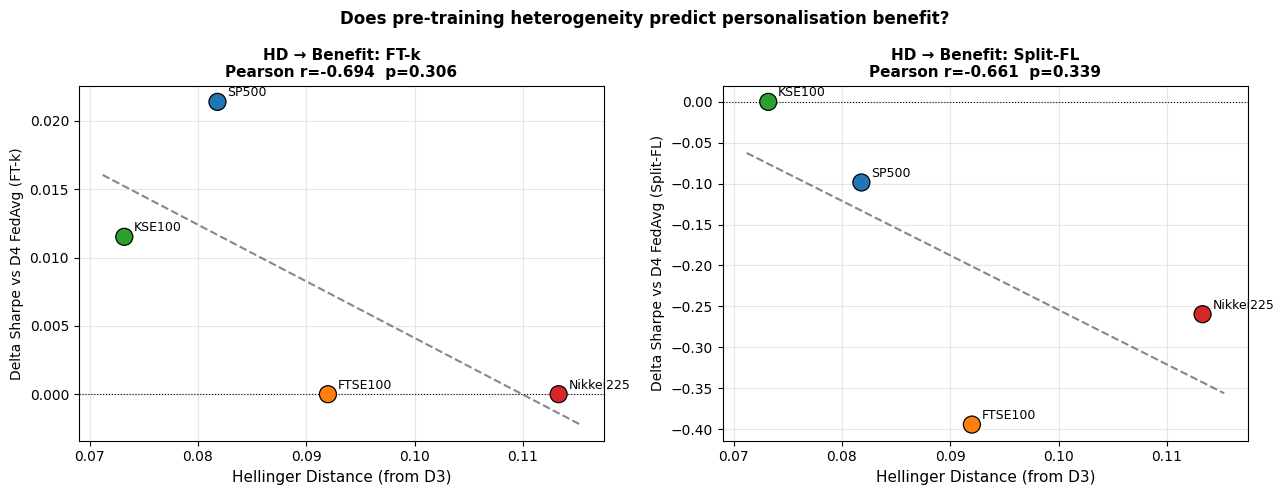

FT-k   : r=-0.694  p=0.306
Split-FL: r=-0.661  p=0.339


In [23]:
hd_vals   = [HD_SCORES[m] for m in MARKETS]
ft_deltas = [np.mean(ft_sharpes[best_k[m]][m]) - np.mean(fedavg_sharpes[m]) for m in MARKETS]
sfl_deltas= [np.mean(splitfl_sharpes[m])       - np.mean(fedavg_sharpes[m]) for m in MARKETS]

r_ft,  p_ft  = pearsonr(hd_vals, ft_deltas)
r_sfl, p_sfl = pearsonr(hd_vals, sfl_deltas)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, deltas, r, p, title, method_label in [
    (axes[0], ft_deltas,  r_ft,  p_ft,  'FT-k',     'FT-k'),
    (axes[1], sfl_deltas, r_sfl, p_sfl, 'Split-FL',  'Split-FL'),
]:
    ax.scatter(hd_vals, deltas, s=150, zorder=5,
               c=[COLORS[m] for m in MARKETS], edgecolors='black', linewidth=0.9)
    for m, hd, dv in zip(MARKETS, hd_vals, deltas):
        ax.annotate(m, (hd, dv), textcoords='offset points', xytext=(7, 4), fontsize=9)
    z = np.polyfit(hd_vals, deltas, 1)
    xl = np.linspace(min(hd_vals)-0.002, max(hd_vals)+0.002, 100)
    ax.plot(xl, np.poly1d(z)(xl), '--', color='#555', alpha=0.7, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Hellinger Distance (from D3)', fontsize=11)
    ax.set_ylabel(f'Delta Sharpe vs D4 FedAvg ({method_label})', fontsize=10)
    ax.set_title(f'HD → Benefit: {title}\nPearson r={r:.3f}  p={p:.3f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Does pre-training heterogeneity predict personalisation benefit?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'hd_vs_benefit.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'FT-k   : r={r_ft:.3f}  p={p_ft:.3f}')
print(f'Split-FL: r={r_sfl:.3f}  p={p_sfl:.3f}')

---
## Section 16 — FT-k Ablation Plot

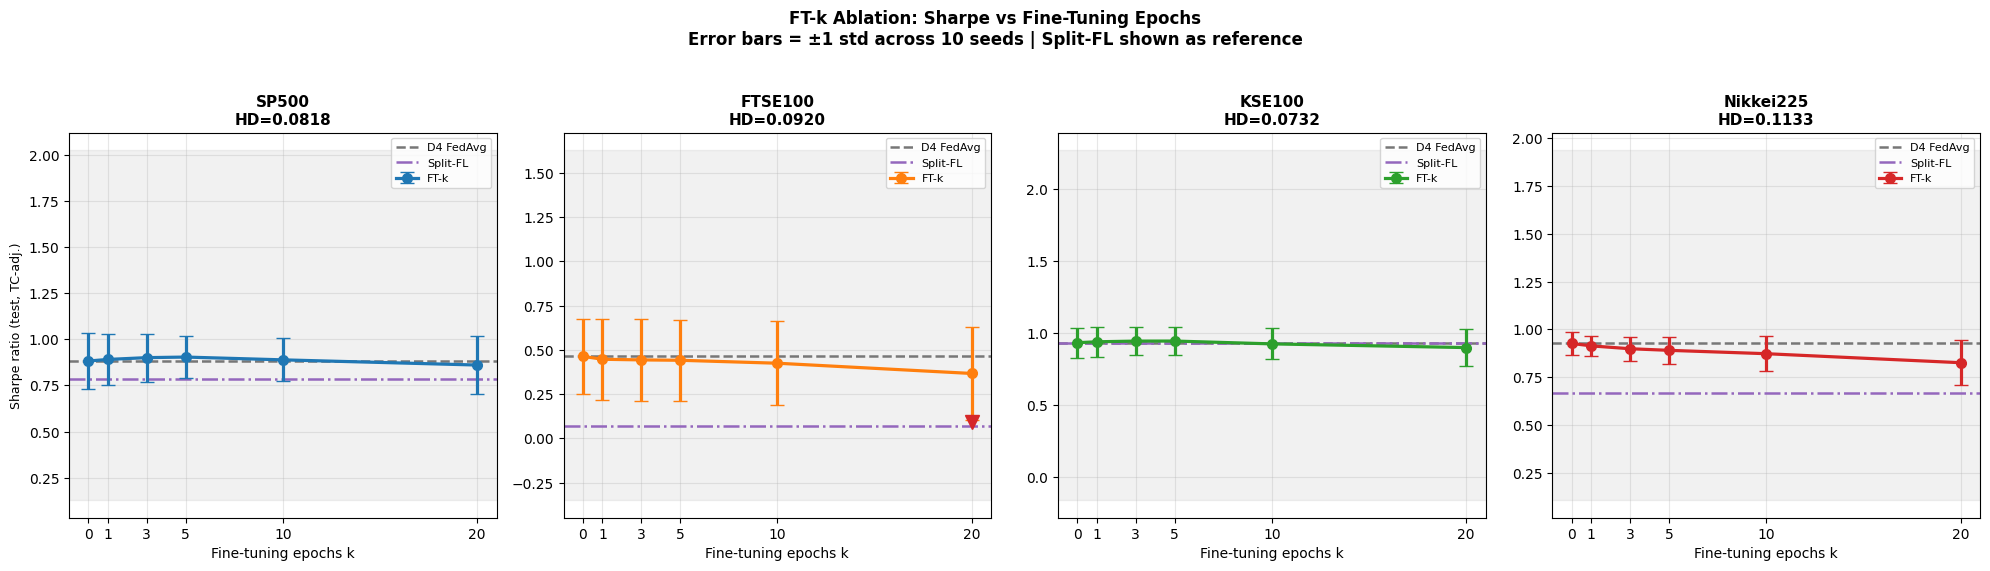

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), sharey=False)

for i, m in enumerate(MARKETS):
    ax = axes[i]
    means = np.array([np.mean(ft_sharpes[k][m]) for k in FINETUNE_EPOCHS])
    stds  = np.array([np.std( ft_sharpes[k][m]) for k in FINETUNE_EPOCHS])

    fa_mean = np.mean(fedavg_sharpes[m])
    _, _, fa_lo, fa_hi = block_bootstrap_sharpe(fedavg_daily42[m])
    ax.axhline(fa_mean, color='#777', linestyle='--', linewidth=1.8,
               label='D4 FedAvg', zorder=2)
    ax.axhspan(fa_lo, fa_hi, color='#777', alpha=0.10, zorder=1)

    sfl_mean = np.mean(splitfl_sharpes[m])
    ax.axhline(sfl_mean, color='#9467bd', linestyle='-.',
               linewidth=1.8, label='Split-FL', zorder=2)

    ax.errorbar(FINETUNE_EPOCHS, means, yerr=stds, fmt='o-',
                color=COLORS[m], capsize=5, linewidth=2.3, markersize=7,
                label='FT-k', zorder=4)

    for j, k in enumerate(FINETUNE_EPOCHS):
        sg = next(r['sig'] for r in stat_table if r['market']==m and r['k']==k)
        if sg == '++':
            ax.plot(k, means[j]+stds[j]+0.015, '*', color='#2ca02c', markersize=13, zorder=5)
        elif sg == '--':
            ax.plot(k, means[j]-stds[j]-0.015, 'v', color='#d62728', markersize=10, zorder=5)

    ax.set_title(f'{m}\nHD={HD_SCORES[m]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Fine-tuning epochs k', fontsize=10)
    if i == 0: ax.set_ylabel('Sharpe ratio (test, TC-adj.)', fontsize=9)
    ax.set_xticks(FINETUNE_EPOCHS)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'FT-k Ablation: Sharpe vs Fine-Tuning Epochs\n'
    'Error bars = ±1 std across 10 seeds | Split-FL shown as reference',
    fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ft_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 17 — Cumulative Returns

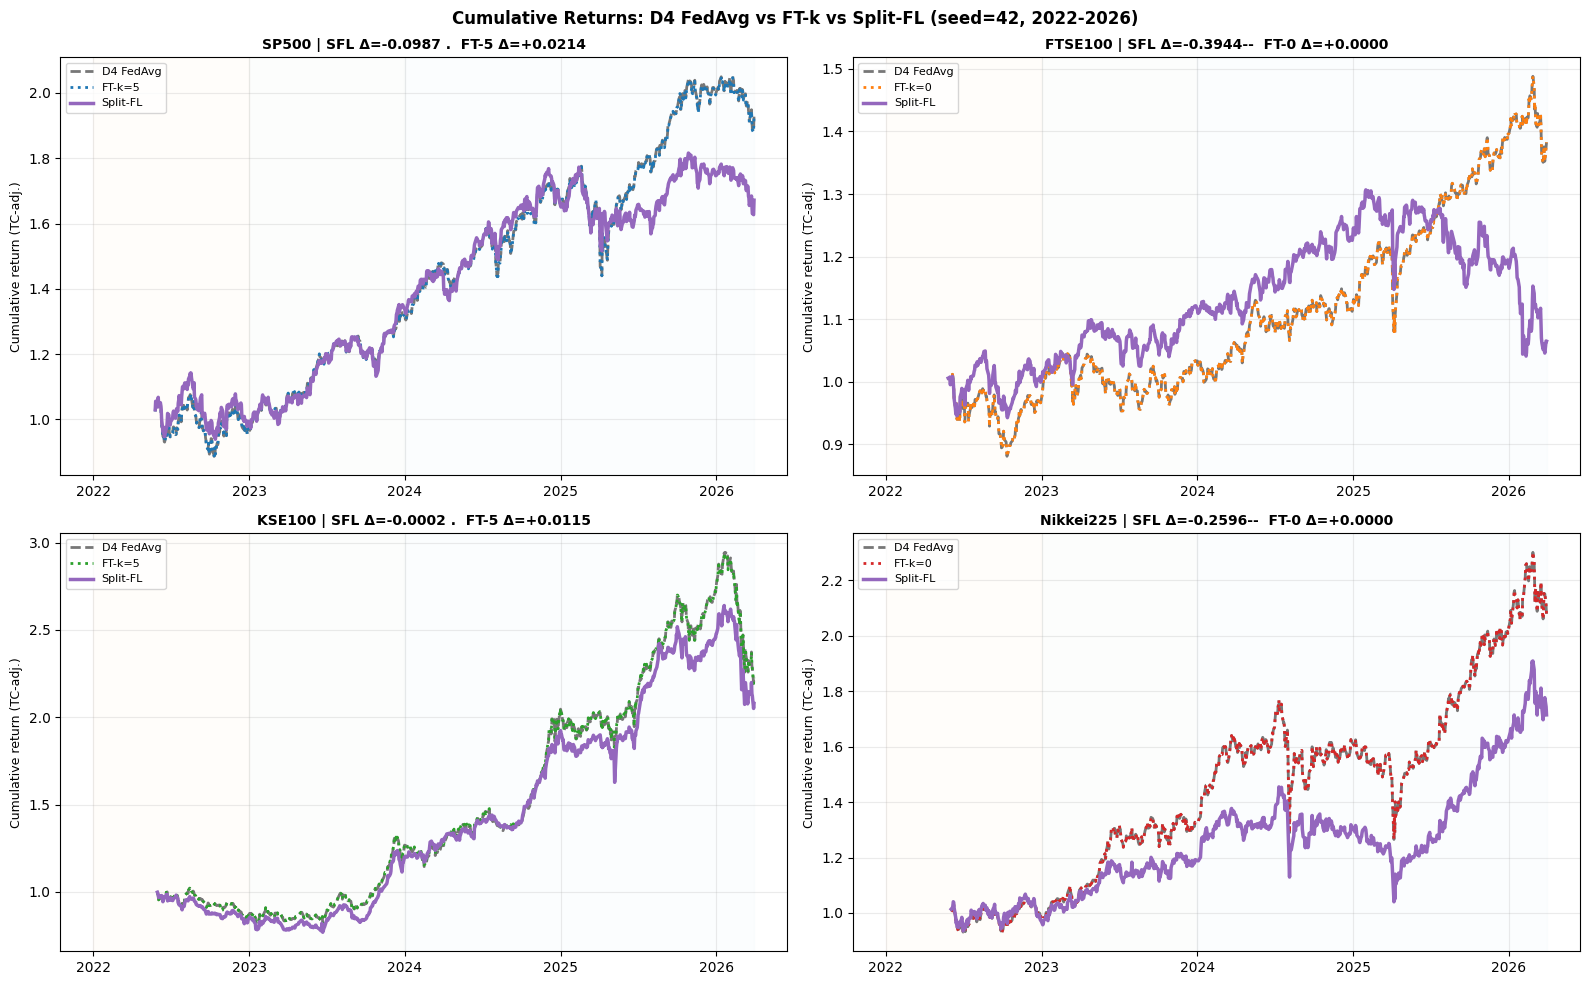

In [25]:
REGIME_COLORS = ['#fff3e0', '#e8f5e9', '#e3f2fd']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, m in enumerate(MARKETS):
    ax = axes[i]
    test_dates = splits[m]['test'].index
    k  = best_k[m]

    fa_res  = evaluate_portfolio(fedavg_models[SEEDS[0]][m], *test_seq[m])
    sfl_res = evaluate_portfolio(splitfl_models[SEEDS[0]][m], *test_seq[m])
    ft_res  = ft_metrics42[k][m]

    n_off  = len(test_dates) - len(fa_res['cum_ret'])
    d_plot = test_dates[n_off:]

    ax.plot(d_plot, fa_res['cum_ret'],  color='#777', linewidth=2.0,
            linestyle='--', label='D4 FedAvg', zorder=3)
    ax.plot(d_plot[:len(ft_res['cum_ret'])], ft_res['cum_ret'],
            color=COLORS[m], linewidth=2.0, linestyle=':', label=f'FT-k={k}', zorder=4)
    ax.plot(d_plot[:len(sfl_res['cum_ret'])], sfl_res['cum_ret'],
            color='#9467bd', linewidth=2.5, label='Split-FL', zorder=5)

    for j, (rname,(rs,re)) in enumerate(REGIMES.items()):
        ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                   alpha=0.13, color=REGIME_COLORS[j])

    sfl_d = np.mean(splitfl_sharpes[m]) - np.mean(fedavg_sharpes[m])
    ft_d  = np.mean(ft_sharpes[k][m])   - np.mean(fedavg_sharpes[m])
    sfl_sig = next(r['sig'] for r in stat_table_sfl if r['market']==m)
    ax.set_title(f'{m} | SFL Δ={sfl_d:+.4f}{sfl_sig}  FT-{k} Δ={ft_d:+.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative return (TC-adj.)', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.25)

plt.suptitle('Cumulative Returns: D4 FedAvg vs FT-k vs Split-FL (seed=42, 2022-2026)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cumret.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 18 — Regime-Decomposed Sharpe

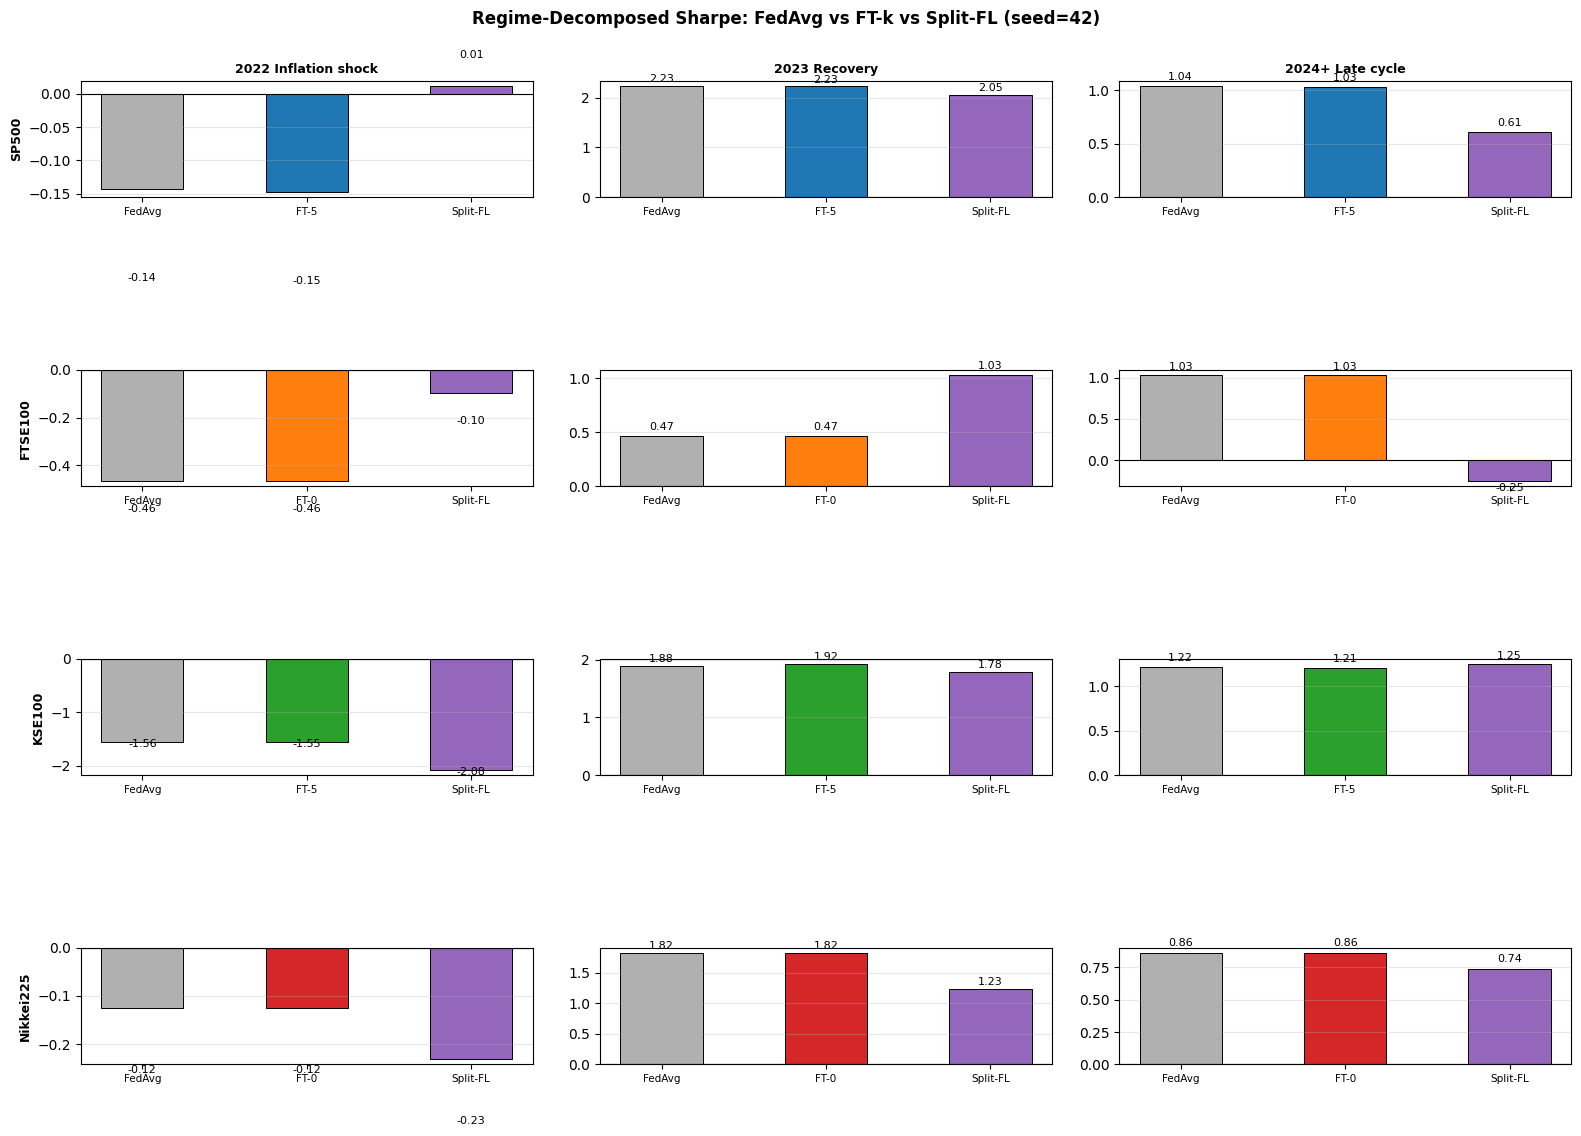

In [26]:
def regime_sharpe(daily_rets, test_dates):
    n_off  = len(test_dates) - len(daily_rets)
    rdates = test_dates[n_off:]
    out = {}
    for name,(rs,re) in REGIMES.items():
        mask = (rdates >= rs) & (rdates <= re)
        r    = daily_rets[mask]
        out[name] = ((r.mean()-RF_DAILY)/(r.std()+1e-9)*TRADING_DAYS**0.5
                     if len(r) >= 10 else np.nan)
    return out

regime_list = list(REGIMES.keys())
fig, axes = plt.subplots(len(MARKETS), len(REGIMES), figsize=(16, 12))

for ri, m in enumerate(MARKETS):
    td = splits[m]['test'].index
    k  = best_k[m]
    fa_reg  = regime_sharpe(fedavg_daily42[m],  td)
    ft_reg  = regime_sharpe(ft_daily42[k][m],   td)
    sfl_reg = regime_sharpe(splitfl_daily42[m],  td)
    for ci, rname in enumerate(regime_list):
        ax = axes[ri][ci]
        vals = [fa_reg[rname], ft_reg[rname], sfl_reg[rname]]
        bars = ax.bar(['FedAvg', f'FT-{k}', 'Split-FL'], vals,
                      color=['#b0b0b0', COLORS[m], '#9467bd'],
                      width=0.5, edgecolor='black', linewidth=0.7)
        ax.axhline(0, color='black', linewidth=0.8)
        for bar, val in zip(bars, vals):
            if val is not None and not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2., val+(0.04 if val>=0 else -0.14),
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        if ri == 0: ax.set_title(rname, fontsize=9, fontweight='bold')
        if ci == 0: ax.set_ylabel(m, fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7.5)
        ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Regime-Decomposed Sharpe: FedAvg vs FT-k vs Split-FL (seed=42)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'regime.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 19 — Final Summary

In [27]:
print('='*115)
print('DELIVERABLE 4 — FINAL RESULTS')
print(f'Test {TEST_START[:4]}-{TEST_END[:4]} | Window={WINDOW}d | {len(SEEDS)} seeds | hidden={HIDDEN_DIM}, layers={NUM_LAYERS}')
print(f'Significance: JK (Memmel 2003) + Wilcoxon signed-rank, both p<0.05')
print('='*115)

print(f"\n{'Market':<12} {'HD':>7} {'D3 FedAvg':>11} {'D4 FedAvg':>11} "
      f"{'FT-k best':>12} {'FT sig':>7} {'Split-FL':>12} {'SFL sig':>8}")
print('-'*90)
for m in MARKETS:
    k     = best_k[m]
    d3fa  = D3_SHARPE['FedAvg'][m]
    d4fa  = np.mean(fedavg_sharpes[m])
    ft_s  = np.mean(ft_sharpes[k][m])
    ft_sg = next(r['sig'] for r in stat_table if r['market']==m and r['k']==k)
    sfl_s = np.mean(splitfl_sharpes[m])
    sfl_sg= next(r['sig'] for r in stat_table_sfl if r['market']==m)
    print(f'{m:<12} {HD_SCORES[m]:>7.4f} {d3fa:>+11.4f} {d4fa:>+11.4f} '
          f'{ft_s:>+12.4f} {ft_sg:>7} {sfl_s:>+12.4f} {sfl_sg:>8}')

print()
hd_vals = [HD_SCORES[m] for m in MARKETS]
r_ft,  p_ft  = pearsonr(hd_vals,
    [np.mean(ft_sharpes[best_k[m]][m])-np.mean(fedavg_sharpes[m]) for m in MARKETS])
r_sfl, p_sfl = pearsonr(hd_vals,
    [np.mean(splitfl_sharpes[m])-np.mean(fedavg_sharpes[m]) for m in MARKETS])
print(f'HD -> benefit (FT-k)   : Pearson r={r_ft:.3f}  p={p_ft:.3f}')
print(f'HD -> benefit (Split-FL): Pearson r={r_sfl:.3f}  p={p_sfl:.3f}')
print()
print('='*115)
figs = sorted(f for f in os.listdir(FIGURES_DIR) if f.endswith('.png'))
print(f'Figures saved to {FIGURES_DIR}/: {figs}')
print('='*115)

DELIVERABLE 4 — FINAL RESULTS
Test 2022-2026 | Window=100d | 10 seeds | hidden=96, layers=2
Significance: JK (Memmel 2003) + Wilcoxon signed-rank, both p<0.05

Market            HD   D3 FedAvg   D4 FedAvg    FT-k best  FT sig     Split-FL  SFL sig
------------------------------------------------------------------------------------------
SP500         0.0818     +0.9498     +0.8823      +0.9037       .      +0.7837        .
FTSE100       0.0920     +0.5099     +0.4636      +0.4636       .      +0.0692       --
KSE100        0.0732     +0.9375     +0.9314      +0.9429       .      +0.9311        .
Nikkei225     0.1133     +0.8664     +0.9259      +0.9259       .      +0.6663       --

HD -> benefit (FT-k)   : Pearson r=-0.694  p=0.306
HD -> benefit (Split-FL): Pearson r=-0.661  p=0.339

Figures saved to Figures_imp1/: ['cumret.png', 'ft_ablation.png', 'hd_vs_benefit.png', 'regime.png']


---
## Section 20 — Ditto

Ditto (Li et al., NeurIPS 2021) trains a separate local model per client alongside the standard FedAvg global model. Each round, the local model takes gradient steps on the client's own data with a proximal term pulling it toward the current global weights. The global model is updated by standard FedAvg and is never itself personalised.

The key difference from FT-k: the local model develops its own trajectory from the beginning of training rather than being initialised from a converged global model. This avoids catastrophic forgetting of any local structure learned early on.

We test μ ∈ {0.01, 0.1, 1.0} and select the best value per market on the validation set. At μ→∞ the local model collapses to the global (FedAvg). At μ=0 it trains independently (local-only).

In [28]:
# DITTO IMPLEMENTATION

def ditto_local_step(local_model, global_model, market, mu,
                     epochs=LOCAL_EPOCHS, lr=LOCAL_LR, bs=BATCH_SIZE):
    """
    One Ditto local update: optimise local model on client data with
    a proximal term ||w_local - w_global||^2 pulling toward the global.

    Unlike FT-k, this is called every round during training, not post-hoc.
    The global model weights are detached — they are a fixed reference
    for this round's proximal term, not updated here.

    Returns updated local model (in-place, also returned for clarity).
    """
    # Cache current global weights as fixed reference for proximal term
    global_params = {n: p.detach().clone()
                     for n, p in global_model.named_parameters()}

    opt = torch.optim.Adam(local_model.parameters(), lr=lr)
    local_model.train()
    X_tr, y_tr = train_seq[market]
    n = X_tr.shape[0]

    for _ in range(epochs):
        perm, prev_w = torch.randperm(n, device=device), None
        for s in range(0, n, bs):
            idx = perm[s:s+bs]; x_b, y_b = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            w_b  = local_model(x_b)
            loss = portfolio_loss(w_b, y_b, prev_w)
            # Proximal term: μ/2 * ||w_local - w_global||^2
            prox = sum(((p - global_params[nm])**2).sum()
                       for nm, p in local_model.named_parameters())
            loss = loss + (mu / 2.0) * prox
            loss.backward()
            nn.utils.clip_grad_norm_(local_model.parameters(), GRAD_CLIP)
            opt.step()
            prev_w = w_b.detach()

    return local_model


def run_ditto(seed, mu, markets=None, verbose=False):
    """
    Full Ditto training run for one seed and one mu value.

    Each round:
      1. Global model: standard FedAvg local training + aggregation
      2. Local models: one Ditto proximal step per client toward current global

    The global model is the same as standard FedAvg — Ditto does not
    change how the global model is trained, only adds the local models.
    Early stopping is on aggregate global val Sharpe (same criterion as FedAvg).

    Returns:
      local_models  : dict {market -> best local model by val Sharpe}
      global_models : dict {market -> best global model (same as FedAvg)}
      n_rounds      : int
    """
    if markets is None: markets = MARKETS
    np.random.seed(seed)

    # Global model — trained exactly like FedAvg
    global_models  = {m: make_model(m, seed) for m in markets}
    # Local models — one per client, initialised identically
    local_models   = {m: make_model(m, seed) for m in markets}

    history_global = {m: [] for m in markets}
    history_local  = {m: [] for m in markets}

    best_agg       = -np.inf
    best_global_sd = {m: copy.deepcopy(global_models[m].state_dict()) for m in markets}
    best_local_sd  = {m: copy.deepcopy(local_models[m].state_dict())  for m in markets}
    best_local_val = {m: -np.inf for m in markets}

    pat, nrds = 0, 0

    for rnd in range(1, MAX_FL_ROUNDS + 1):
        # Step 1: FedAvg global update
        sds, sizes = [], []
        for m in markets:
            sds.append(local_train(global_models[m], *train_seq[m]))
            sizes.append(len(train_seq[m][0]))
        gsd = fedavg_aggregate(sds, sizes)
        for m in markets: global_models[m].load_state_dict(gsd)

        # Step 2: Ditto local update (each client, toward current global)
        for m in markets:
            ditto_local_step(local_models[m], global_models[m], m, mu)

        # Validation: global for early stopping, local for best-local
        agg = 0.0
        for m in markets:
            gs = evaluate_portfolio(global_models[m], *val_seq[m])['sharpe']
            ls = evaluate_portfolio(local_models[m],  *val_seq[m])['sharpe']
            history_global[m].append(gs)
            history_local[m].append(ls)
            agg += gs

            # Track best local model per market independently
            if ls > best_local_val[m]:
                best_local_val[m]  = ls
                best_local_sd[m]   = copy.deepcopy(local_models[m].state_dict())

        agg /= len(markets); nrds = rnd

        if verbose: print(f'  Round {rnd:3d} global_agg={agg:+.4f} pat={pat}')

        # Early stopping on global model (standard FedAvg criterion)
        if agg > best_agg + 1e-4:
            best_agg       = agg
            best_global_sd = {m: copy.deepcopy(global_models[m].state_dict()) for m in markets}
            pat = 0
        else:
            pat += 1
            if pat >= PATIENCE: break

    # Restore best weights
    for m in markets:
        global_models[m].load_state_dict(best_global_sd[m])
        local_models[m].load_state_dict(best_local_sd[m])

    return local_models, global_models, nrds


# MU SELECTION: val-set local Sharpe at each mu, seed=42
print('Ditto μ selection (seed=42, val Sharpe of local model):')
print(f'μ grid: {DITTO_MU_GRID}')
print('='*65)

mu_val_scores = {mu: {} for mu in DITTO_MU_GRID}

t0 = time.time()
for mu in DITTO_MU_GRID:
    lm, gm, nrds = run_ditto(SEEDS[0], mu=mu)
    for m in MARKETS:
        res = evaluate_portfolio(lm[m], *val_seq[m])
        mu_val_scores[mu][m] = res['sharpe']

print(f'\nDone in {(time.time()-t0)/60:.1f} min')
print(f"\n{'Market':<12}" + '  '.join(f'μ={mu}' for mu in DITTO_MU_GRID) + '  SELECTED')
print('-'*65)

best_mu = {}
for m in MARKETS:
    scores  = [mu_val_scores[mu][m] for mu in DITTO_MU_GRID]
    best    = DITTO_MU_GRID[int(np.argmax(scores))]
    best_mu[m] = best
    vals = '  '.join(f'{mu_val_scores[mu][m]:+.4f}' for mu in DITTO_MU_GRID)
    print(f'{m:<12}  {vals}  -> {best}')

print(f'\nSelected μ per market: {best_mu}')


# MAIN DITTO RUN: 10 seeds, per-market best mu
print('\nDitto training (10 seeds, per-market μ)...')
print('='*72)

t0 = time.time()
ditto_sharpes   = {m: [] for m in MARKETS}
ditto_daily42   = {}
ditto_metrics42 = {}

for si, seed in enumerate(SEEDS):
    # For simplicity use the best mu across markets (most common selection)
    # If markets selected different mu values, run once per unique mu
    unique_mus = list(set(best_mu.values()))

    seed_local_models = {}
    for mu in unique_mus:
        markets_for_mu = [m for m in MARKETS if best_mu[m] == mu]
        if not markets_for_mu: continue
        lm, _, _ = run_ditto(seed, mu=mu, markets=markets_for_mu)
        seed_local_models.update(lm)

    for m in MARKETS:
        res = evaluate_portfolio(seed_local_models[m], *test_seq[m])
        ditto_sharpes[m].append(res['sharpe'])
        if seed == SEEDS[0]:
            ditto_daily42[m]   = res['daily_rets']
            ditto_metrics42[m] = res

    if (si+1) % 5 == 0 or si == 0:
        print(f'  Seed {seed} ({si+1}/{len(SEEDS)})')

print(f'\nDone in {(time.time()-t0)/60:.1f} min')

# RESULTS TABLE
print(f"\n{'Market':<12} {'Ditto':>12} {'D4 FedAvg':>12} {'Delta':>8} {'JK p':>8} {'Wil p':>8} {'Sig':>5}")
print('-'*70)

stat_table_ditto = []
for m in MARKETS:
    mean_s = np.mean(ditto_sharpes[m]); std_s = np.std(ditto_sharpes[m])
    delta  = mean_s - np.mean(fedavg_sharpes[m])
    jk_z, jk_p = jobson_korkie(ditto_daily42[m], fedavg_daily42[m])
    _,    wil_p = wilcoxon_test(ditto_sharpes[m], fedavg_sharpes[m])
    _, _, ci_lo, ci_hi = block_bootstrap_sharpe(ditto_daily42[m])
    dual = (jk_p < 0.05) and (wil_p < 0.05)
    sig  = '++' if (dual and delta > 0) else ('--' if (dual and delta < 0) else ' .')
    print(f'{m:<12} {mean_s:>+12.4f} {np.mean(fedavg_sharpes[m]):>+12.4f} '
          f'{delta:>+8.4f} {jk_p:>8.4f} {wil_p:>8.4f} {sig:>5}')
    stat_table_ditto.append(dict(market=m, mean_s=mean_s, std_s=std_s,
                                 delta=delta, jk_p=jk_p, wil_p=wil_p,
                                 sig=sig, ci_lo=ci_lo, ci_hi=ci_hi,
                                 mu=best_mu[m]))

# FINAL FOUR-WAY COMPARISON
print('\n' + '='*100)
print('FINAL COMPARISON: D4 FedAvg | FT-k | Split-FL | Ditto')
print('='*100)
print(f"{'Market':<12} {'HD':>7} {'D4 FedAvg':>12} {'FT-k':>12} {'Split-FL':>12} {'Ditto':>12} {'Winner'}")
print('-'*80)
for m in MARKETS:
    fa_s   = np.mean(fedavg_sharpes[m])
    ft_s   = np.mean(ft_sharpes[best_k[m]][m])
    sfl_s  = np.mean(splitfl_sharpes[m])
    dit_s  = np.mean(ditto_sharpes[m])
    best_s = max(fa_s, ft_s, sfl_s, dit_s)
    winner = ['FedAvg','FT-k','Split-FL','Ditto'][[fa_s,ft_s,sfl_s,dit_s].index(best_s)]
    print(f'{m:<12} {HD_SCORES[m]:>7.4f} {fa_s:>+12.4f} {ft_s:>+12.4f} '
          f'{sfl_s:>+12.4f} {dit_s:>+12.4f} {winner}')

# HD -> Ditto benefit correlation
hd_vals     = [HD_SCORES[m] for m in MARKETS]
ditto_deltas= [np.mean(ditto_sharpes[m])-np.mean(fedavg_sharpes[m]) for m in MARKETS]
r_ditto, p_ditto = pearsonr(hd_vals, ditto_deltas)
print(f'\nHD -> Ditto benefit: Pearson r={r_ditto:.3f}  p={p_ditto:.3f}')

Ditto μ selection (seed=42, val Sharpe of local model):
μ grid: [0.01, 0.1, 0.3, 1.0]

Done in 5.9 min

Market      μ=0.01  μ=0.1  μ=0.3  μ=1.0  SELECTED
-----------------------------------------------------------------
SP500         +2.1299  +2.0901  +2.1366  +2.3139  -> 1.0
FTSE100       +0.4110  +0.2614  +0.3705  +0.4223  -> 1.0
KSE100        +0.9895  +0.8489  +1.0754  +1.2538  -> 1.0
Nikkei225     +1.0366  +1.0488  +1.1385  +1.1609  -> 1.0

Selected μ per market: {'SP500': 1.0, 'FTSE100': 1.0, 'KSE100': 1.0, 'Nikkei225': 1.0}

Ditto training (10 seeds, per-market μ)...
  Seed 42 (1/10)
  Seed 46 (5/10)
  Seed 51 (10/10)

Done in 15.6 min

Market              Ditto    D4 FedAvg    Delta     JK p    Wil p   Sig
----------------------------------------------------------------------
SP500             +0.6773      +0.8823  -0.2050   0.0000   0.1309     .
FTSE100           +0.4760      +0.4636  +0.0123   0.3280   0.7695     .
KSE100            +0.9207      +0.9314  -0.0106   0.0224   0.9